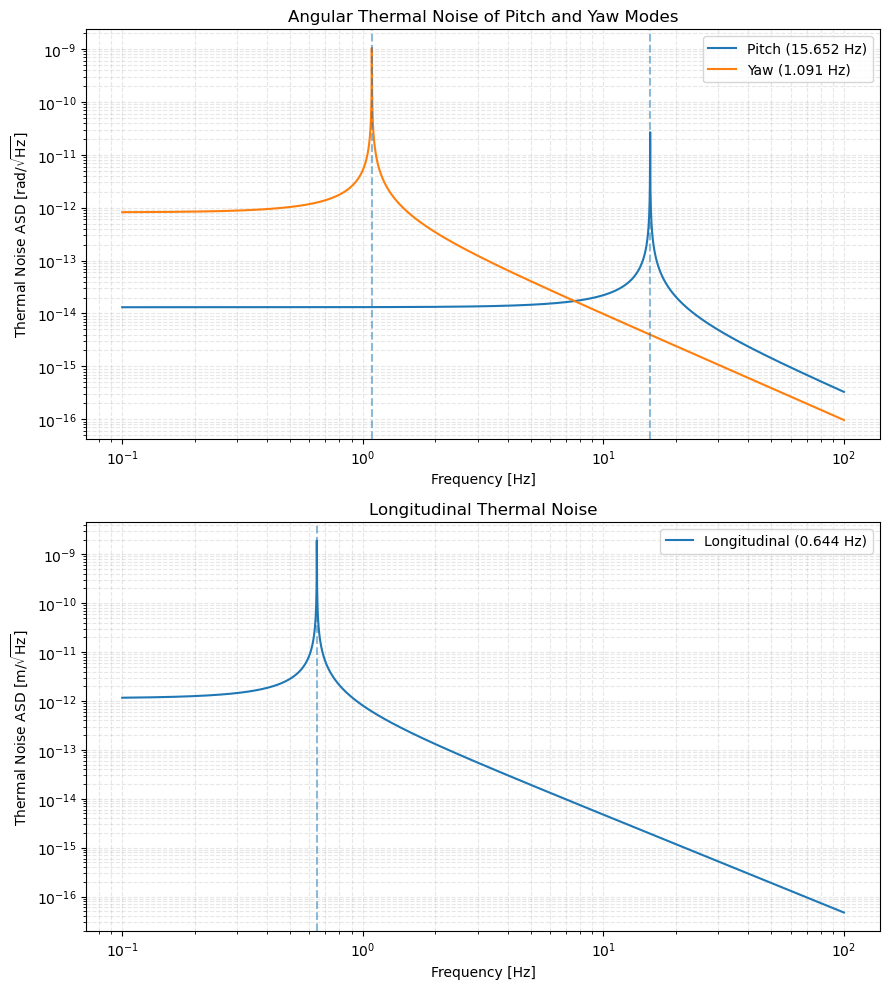

In [55]:
"""
Thermal Noise Analysis of Pendulum Suspension Modes
===================================================

This cell computes the thermal noise Amplitude Spectral Density (ASD) of the
experimentally measured longitudinal, pitch, and yaw modes of a single-stage
pendulum suspension.

Starting from the thermal noise ASD of a viscously damped harmonic oscillator,

A(ω) = √[4kBTγ / ((k - mω²)² + (γω)²)]

and using

γ = mω₀/Q
k = mω₀²

the expression becomes

A(ω) = √{4kBTω₀ / [mQ((ω₀² - ω²)² + (ω₀ω/Q)²)]}

where ω₀ is the resonance angular frequency and Q is the measured quality factor.

For rotational modes, the mass term m is replaced by the corresponding moment
of inertia I, yielding an ASD in rad/√Hz. Angular ASD is converted to an
equivalent linear displacement ASD using x = rθ, allowing direct comparison
between all suspension modes in units of m/√Hz.
"""

import numpy as np
import matplotlib.pyplot as plt

# Physical constants
k_B = 1.380649e-23      # Boltzmann constant [J/K]
T = 300                 # Temperature [K]

# Pendulum parameters
g = 9.81                # Gravitational acceleration [m/s²]
l = 0.6                 # Suspension length [m]
m = 0.102               # Test mass [kg]

# Moments of inertia
I_x = 37.5e-6           # Roll inertia [kg m²]
I_y = 22.0e-6           # Pitch inertia [kg m²]
I_z = 22.7e-6           # Yaw inertia [kg m²]

# Experimentally measured resonance frequencies [Hz]
f0_long = 0.6442         
f0_pitch = 15.6517
f0_yaw = 1.0908

# Experimentally measured quality factors
Q_long = 1896
Q_pitch = 2962
Q_yaw = 2204

# Angular resonance frequencies [rad/s]
omega0_long = 2*np.pi*f0_long
omega0_pitch = 2*np.pi*f0_pitch
omega0_yaw = 2*np.pi*f0_yaw

# Frequency axis
freqs = np.logspace(-1, 2, 5000)
omega = 2*np.pi*freqs

# Thermal noise ASD
asd_long = np.sqrt((4*k_B*T*omega0_long)/(m*Q_long*((omega0_long**2-omega**2)**2+(omega0_long*omega/Q_long)**2)))
asd_pitch_rad = np.sqrt((4*k_B*T*omega0_pitch)/(I_y*Q_pitch*((omega0_pitch**2-omega**2)**2+(omega0_pitch*omega/Q_pitch)**2)))
asd_yaw_rad = np.sqrt((4*k_B*T*omega0_yaw)/(I_z*Q_yaw*((omega0_yaw**2-omega**2)**2+(omega0_yaw*omega/Q_yaw)**2)))

#Combined Plot 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,10))

# Pitch and Yaw thermal noise [rad/√Hz]
ax1.loglog(freqs, asd_pitch, linewidth=1.5, label=f'Pitch ({f0_pitch:.3f} Hz)')
ax1.loglog(freqs, asd_yaw, linewidth=1.5, label=f'Yaw ({f0_yaw:.3f} Hz)')
ax1.axvline(f0_pitch, linestyle='--', alpha=0.5)
ax1.axvline(f0_yaw, linestyle='--', alpha=0.5)
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel(r'Thermal Noise ASD [rad/$\sqrt{\mathrm{Hz}}$]')
ax1.set_title('Angular Thermal Noise of Pitch and Yaw Modes')
ax1.grid(True, which='both', linestyle='--', alpha=0.3)
ax1.legend()

# Longitudinal thermal noise [m/√Hz]
ax2.loglog(freqs, asd_long, linewidth=1.5, label=f'Longitudinal ({f0_long:.3f} Hz)')
ax2.axvline(f0_long, linestyle='--', alpha=0.5)
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylabel(r'Thermal Noise ASD [m/$\sqrt{\mathrm{Hz}}$]')
ax2.set_title('Longitudinal Thermal Noise')
ax2.grid(True, which='both', linestyle='--', alpha=0.3)
ax2.legend()
plt.tight_layout()
plt.show()

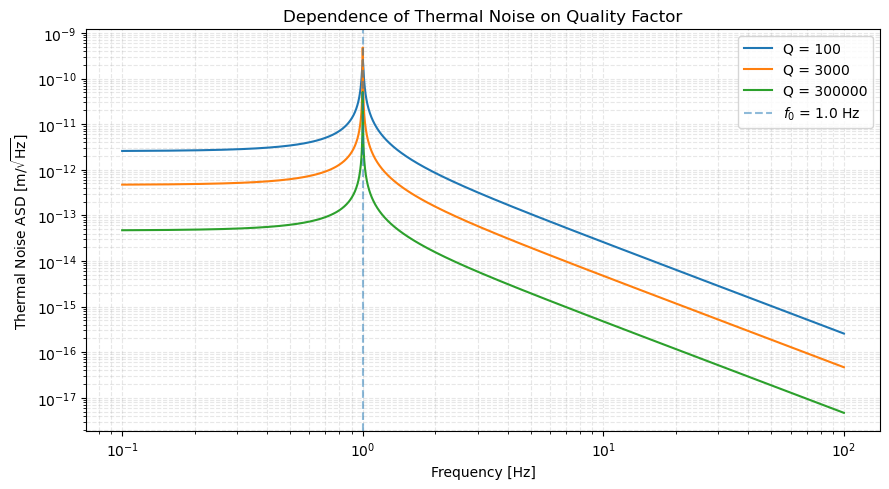

In [56]:
"""
Dependence of Thermal Noise on Quality Factor
=============================================

This cell illustrates how the thermal noise ASD of a representative
oscillator varies with mechanical quality factor Q. The resonance
frequency is held fixed while Q is varied over a wide range.
"""

# Reference resonance frequency [Hz]
f0_ref = 1.0
omega0_ref = 2*np.pi*f0_ref

# Trial quality factors
Q_values = [100, 3000, 300000]

plt.figure(figsize=(9,5))

for Q in Q_values:

    # Thermal noise ASD [m/√Hz]
    asd_Q = np.sqrt((4*k_B*T*omega0_ref)/(m*Q*((omega0_ref**2-omega**2)**2+(omega0_ref*omega/Q)**2)))

    plt.loglog(freqs, asd_Q, linewidth=1.5, label=f'Q = {Q}')

# Reference resonance frequency
plt.axvline(f0_ref, linestyle='--', alpha=0.5, label=fr'$f_0$ = {f0_ref:.1f} Hz')
plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Thermal Noise ASD [m/$\sqrt{\mathrm{Hz}}$]')
plt.title('Dependence of Thermal Noise on Quality Factor')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

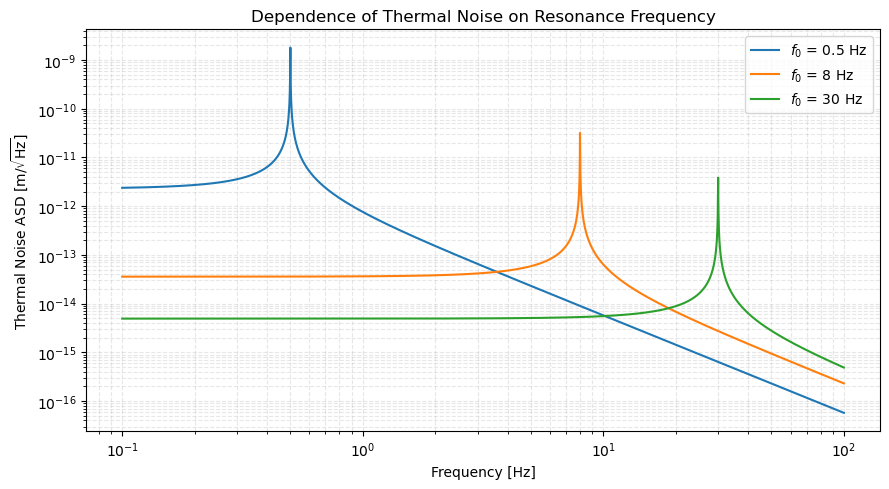

In [57]:
"""
Dependence of Thermal Noise on Resonance Frequency
==================================================

This cell illustrates how the thermal noise ASD of a representative
oscillator varies with resonance frequency f₀. The quality factor
is held fixed while the resonance frequency is varied.
"""

# Reference quality factor
Q_ref = 1000

# Trial resonance frequencies [Hz]
f0_values = [0.5, 8, 30]

plt.figure(figsize=(9,5))

for f0 in f0_values:

    # Angular resonance frequency [rad/s]
    omega0 = 2*np.pi*f0

    # Thermal noise ASD [m/√Hz]
    asd_f0 = np.sqrt((4*k_B*T*omega0)/(m*Q_ref*((omega0**2-omega**2)**2+(omega0*omega/Q_ref)**2)))

    plt.loglog(freqs, asd_f0, linewidth=1.5, label=fr'$f_0$ = {f0} Hz')

plt.xlabel('Frequency [Hz]')
plt.ylabel(r'Thermal Noise ASD [m/$\sqrt{\mathrm{Hz}}$]')
plt.title('Dependence of Thermal Noise on Resonance Frequency')
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()